In [115]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_FILE = BASE_DIR / "data" / "netflix_titles.csv"

### Loading Data

In [116]:
import pandas as pd


df = pd.read_csv(DATA_FILE)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [117]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


### Mission 1

In [118]:
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Column names: {df.columns.tolist()}")
print(f"Column data types: {df.dtypes.astype(str).tolist()}")
print(f"Columns with missing data: {df.columns[df.isna().any()].tolist()}")

Rows: 8807
Columns: 12
Column names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
Column data types: ['str', 'str', 'str', 'str', 'str', 'str', 'str', 'int64', 'str', 'str', 'str', 'str']
Columns with missing data: ['director', 'cast', 'country', 'date_added', 'rating', 'duration']


### Mission 2

In [119]:
missingValuesPerColumn = [len(df[df["director"].isnull()]),
len(df[df["cast"].isnull()]),
len(df[df["country"].isnull()]),
len(df[df["date_added"].isnull()]),
len(df[df["rating"].isnull()]),
len(df[df["duration"].isnull()])]

missingValuesPerColumn


[2634, 825, 831, 10, 4, 3]

In [120]:
## Replace null values by unknown if there are too many rows with missing values for x column
## Drop if the are only few rows with a missing values for x column
df_cleaned = df.dropna(subset=["duration", "rating", "date_added"])
df_cleaned = df_cleaned.fillna({"country": "Unknown", "cast": "Unknown","director": "Unknown"})

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df_cleaned["date_added"] = df_cleaned["date_added"].str.strip()
df_cleaned["date_added"] = pd.to_datetime(df_cleaned["date_added"])

In [123]:
df_cleaned["country"].unique()

<StringArray>
[                                                        'United States',
                                                          'South Africa',
                                                               'Unknown',
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'Turkey',
                                                             'Australia',
 ...
                        'Germany, United States, United Kingdom, Canada',
          'Canada, India, Thailand, United States, United Arab Emirates',
                             'United States, East Germany, West Germany',
                   

In [124]:

df["date_added"].max(), df["date_added"].min()

('September 9, 2021', ' April 15, 2018')

In [125]:
df["release_year"].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

#### Mission 3

In [126]:
df_cleaned["type"].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [127]:
averageReleaseYear = df_cleaned["release_year"].mean()
print(f"average release year: {int(averageReleaseYear)}")

average release year: 2014


In [128]:
print("Oldest title")
df_cleaned.loc[df_cleaned["release_year"].idxmin()]["title"]

Oldest title


'Pioneers: First Women Filmmakers*'

In [129]:
print("newest title")
df_cleaned.loc[df_cleaned["release_year"].idxmax()]["title"]

newest title


'Blood & Water'

In [130]:
print("most common rating")
df_cleaned["rating"].value_counts().index[0]

most common rating


'TV-MA'

#### Mission 4

In [131]:
countryWithMostTitles = df_cleaned.groupby("country").size().sort_values(ascending=False).head(10)
print(f"country with most titles: {countryWithMostTitles.index[0]}, with {countryWithMostTitles.iloc[0]} titles")

country with most titles: United States, with 2809 titles


In [132]:
yearWithMostReleases = df_cleaned.groupby("release_year").size().sort_values(ascending=False)
print(f"year with the most releases: {yearWithMostReleases.index[0]}, with {yearWithMostReleases.iloc[0]} releases")

year with the most releases: 2018, with 1146 releases


In [133]:
df_cleaned["year_added"] = df_cleaned["date_added"].dt.year

In [152]:
titles_per_year = df_cleaned.groupby("year_added").size().sort_index()
titles_per_year.head(3)

year_added
2008    2
2009    2
2010    1
dtype: int64

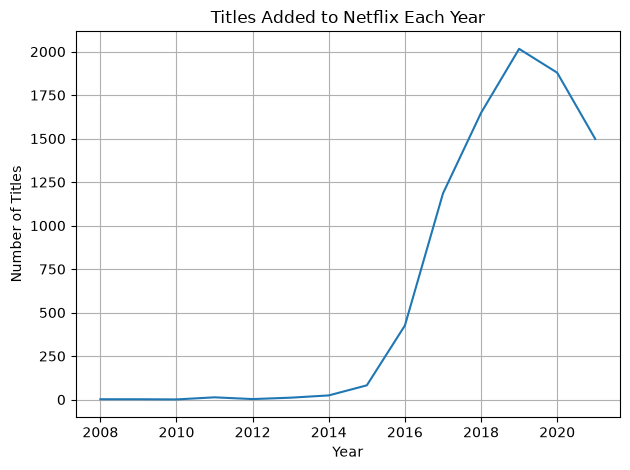

In [ ]:
import matplotlib.pyplot as plt


plt.plot(titles_per_year.index, titles_per_year)
plt.title("Titles Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid()